**04 - Machine Learning**

En este notebook se entrenan y comparan diferentes modelos de Machine Learning para clasificar automáticamente el sentimiento de las reviews.

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [ ]:
#cargar archivo
from google.colab import files

uploaded = files.upload()

Saving amazon_reviews_clean.csv to amazon_reviews_clean.csv


In [ ]:
df = pd.read_csv("amazon_reviews_clean.csv")

df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,review,review_length,review_clean,sentiment
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,[{'small_image_url': 'https://m.media-amazon.c...,B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1658185117948,0,True,Smells like gasoline! Going back! First & most...,1467,smell like gasoline going back first offensive...,Neutro
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1592678549731,0,True,Didn’t work at all lenses loose/broken. These ...,265,didnt work lens loosebroken didnt work idk dam...,Negativo
2,5.0,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1523093017534,0,True,Excellent! I love these. They even come with a...,480,excellent love even come carry case several si...,Positivo
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,1290278495000,18,True,Great laptop backpack! I was searching for a s...,1112,great laptop backpack searching sturdy backpac...,Positivo
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,[],B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,1676601581238,0,True,Best Headphones in the Fifties price range! I'...,284,best headphone fifty price range ive bought he...,Positivo


In [ ]:
#preparar x e y
df = df.dropna(subset=["review_clean", "sentiment"])

X = df["review_clean"]
y = df["sentiment"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
vectorizador = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizador.fit_transform(X_train)
X_test_tfidf = vectorizador.transform(X_test)

**Modelo 1 - Logistic Regression**

In [ ]:
modelo_lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

modelo_lr.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
#predicciones
y_pred_lr = modelo_lr.predict(X_test_tfidf)

In [ ]:
#revisar valores del modelo
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, average="weighted"))
print("Recall:", recall_score(y_test, y_pred_lr, average="weighted"))
print("F1:", f1_score(y_test, y_pred_lr, average="weighted"))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.8048853739113024
Precision: 0.872859707773359
Recall: 0.8048853739113024
F1: 0.8311334931476139
              precision    recall  f1-score   support

    Negativo       0.61      0.73      0.67      1252
      Neutro       0.23      0.50      0.32       682
    Positivo       0.97      0.84      0.90      8055

    accuracy                           0.80      9989
   macro avg       0.60      0.69      0.63      9989
weighted avg       0.87      0.80      0.83      9989



**Modelo 2 - Multinomial Naive Bayes**

Se entrena un modelo Naive Bayes, ampliamente utilizado en problemas de clasificación de texto por su rapidez y buen rendimiento en tareas de procesamiento del lenguaje natural.

In [ ]:
#entrenamiento
modelo_nb = MultinomialNB()

modelo_nb.fit(X_train_tfidf, y_train)

MultinomialNB()

In [ ]:
#predicción
y_pred_nb = modelo_nb.predict(X_test_tfidf)

In [ ]:
#evaluación
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb, average="weighted"))
print("Recall:", recall_score(y_test, y_pred_nb, average="weighted"))
print("F1:", f1_score(y_test, y_pred_nb, average="weighted"))
print(classification_report(y_test, y_pred_nb))

Accuracy: 0.8426268895785364
Precision: 0.8140842282553427
Recall: 0.8426268895785364
F1: 0.7934369997185833
              precision    recall  f1-score   support

    Negativo       0.86      0.31      0.45      1252
      Neutro       0.40      0.00      0.01       682
    Positivo       0.84      1.00      0.91      8055

    accuracy                           0.84      9989
   macro avg       0.70      0.44      0.46      9989
weighted avg       0.81      0.84      0.79      9989



**Modelo 3 - Linear SVM**

Se entrena un modelo Linear SVM, uno de los algoritmos más utilizados en clasificación de texto.

In [ ]:
modelo_svm = LinearSVC(
    class_weight="balanced",
    random_state=42
)

modelo_svm.fit(X_train_tfidf, y_train)

LinearSVC(class_weight='balanced', random_state=42)

In [ ]:
y_pred_svm = modelo_svm.predict(X_test_tfidf)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm, average="weighted"))
print("Recall:", recall_score(y_test, y_pred_svm, average="weighted"))
print("F1:", f1_score(y_test, y_pred_svm, average="weighted"))

print(classification_report(y_test, y_pred_svm))

Accuracy: 0.8564420862949245
Precision: 0.8639436902366632
Recall: 0.8564420862949245
F1: 0.8599136040836948
              precision    recall  f1-score   support

    Negativo       0.67      0.72      0.69      1252
      Neutro       0.31      0.34      0.33       682
    Positivo       0.94      0.92      0.93      8055

    accuracy                           0.86      9989
   macro avg       0.64      0.66      0.65      9989
weighted avg       0.86      0.86      0.86      9989



**Modelo 4 - Random Forest**

Se entrena un modelo Random Forest como alternativa basada en árboles de decisión, con el objetivo de comparar su rendimiento frente a los modelos lineales utilizados anteriormente.

In [ ]:
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo_rf.fit(X_train_tfidf, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = modelo_rf.predict(X_test_tfidf)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average="weighted"))
print("Recall:", recall_score(y_test, y_pred_rf, average="weighted"))
print("F1:", f1_score(y_test, y_pred_rf, average="weighted"))

print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8666533186505155
Precision: 0.8619233798629055
Recall: 0.8666533186505155
F1: 0.8345954123066174
              precision    recall  f1-score   support

    Negativo       0.79      0.50      0.61      1252
      Neutro       0.86      0.07      0.14       682
    Positivo       0.87      0.99      0.93      8055

    accuracy                           0.87      9989
   macro avg       0.84      0.52      0.56      9989
weighted avg       0.86      0.87      0.83      9989



**Tabla comparativa**

In [ ]:
resultados = pd.DataFrame({
    "Modelo": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM",
        "Random Forest"
    ],
    "Accuracy": [
        0.8049,
        0.8426,
        0.8564,
        0.8667
    ],
    "Precision": [
        0.8729,
        0.8141,
        0.8639,
        0.8619
    ],
    "Recall": [
        0.8049,
        0.8426,
        0.8564,
        0.8667
    ],
    "F1-score": [
        0.8311,
        0.7934,
        0.8599,
        0.8346
    ]
})

resultados

,Modelo,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.8049,0.8729,0.8049,0.8311
1,Naive Bayes,0.8426,0.8141,0.8426,0.7934
2,Linear SVM,0.8564,0.8639,0.8564,0.8599
3,Random Forest,0.8667,0.8619,0.8667,0.8346


**Matriz de confusión**

Se representa la matriz de confusión del modelo seleccionado para analizar de forma visual los aciertos y errores de clasificación entre las diferentes categorías de sentimiento.

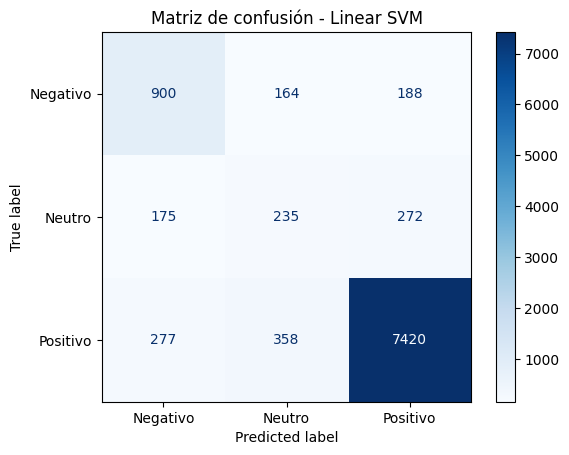

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=modelo_svm.classes_
)

disp.plot(cmap="Blues")

plt.title("Matriz de confusión - Linear SVM")
plt.show()

**Conclusiones**

- Se han entrenado y comparado cuatro modelos de Machine Learning para la clasificación del sentimiento de las reviews.

- Aunque Random Forest obtuvo la mayor accuracy, el modelo Linear SVM consiguió el mejor equilibrio entre las tres clases y el mayor F1-score ponderado.

- La matriz de confusión muestra que el modelo clasifica correctamente la mayoría de las opiniones positivas y obtiene un buen rendimiento con las opiniones negativas.

- La principal dificultad se encuentra en la clasificación de las opiniones neutras, ya que suelen compartir características tanto con las positivas como con las negativas.

- Por su rendimiento global y equilibrio entre métricas, se selecciona **Linear SVM** como modelo final para el resto del proyecto.

In [ ]:
#guardar modelo
import pickle

with open("modelo_sentimiento.pkl", "wb") as archivo:
    pickle.dump(modelo_svm, archivo)

In [ ]:
#guarrdar vectorizador
with open("vectorizador_tfidf.pkl", "wb") as archivo:
    pickle.dump(vectorizador, archivo)

In [ ]:
from google.colab import files

files.download("modelo_sentimiento.pkl")
files.download("vectorizador_tfidf.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>